# 07 — Blended Ensemble

**Dataset:** Inside Airbnb — New York City (open data, 2025–2026)  
**Goal:** Combine OOF predictions from all trained models into an optimally-weighted blend.

All component models use **identical CV splits** (`KFold(5, shuffle=True, random_state=42)`), making OOF blending statistically sound.

Blending strategy:
1. **Equal-weight average** — sanity baseline.
2. **Weight optimisation on OOF** — find weights `w_i ≥ 0, sum=1` that minimise OOF MSE (`scipy.optimize.minimize` with SLSQP).

Outputs:
- `outputs/blend_weights.json`
- `outputs/test_local_pred_blend.npy`

## 1. Setup & Load OOFs / Submissions

In [1]:
import os
os.environ['PYTHONWARNINGS'] = 'ignore'  # also silences warnings from n_jobs=-1 joblib subprocesses

import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
OUT_DIR = Path('../outputs')
DATA_DIR = Path('../data')
print('OUT_DIR =', OUT_DIR.resolve())

OUT_DIR = /Users/bashkal/Desktop/ML/ML-Final/Internship/outputs


In [2]:
# Section IV.C: Use Development targets for OOF evaluation
train_local_df = pd.read_parquet(OUT_DIR / 'train_local.parquet')
test_local_df  = pd.read_parquet(OUT_DIR / 'test_local.parquet')

TARGET = 'blocked_days_Q1_2026'
y_dev  = train_local_df[TARGET].astype(float).values
y_test = test_local_df[TARGET].astype(float).values

print(f'Development set y shape: {y_dev.shape}')
print(f'Local Test set y shape : {y_test.shape}')


Development set y shape: (29008,)
Local Test set y shape : (7253,)


In [3]:
# Pick whichever OOFs are present on disk. 
# OOFs here correspond to the training_local (Development) set.
candidates = {
    'LinearRegression': 'oof_LinearRegression.npy',
    'RandomForest'    : 'oof_RandomForest.npy',
    'GradientBoosting': 'oof_GradientBoosting.npy',
    'XGBoost'         : 'oof_XGBoost.npy',
    'MLP'             : 'oof_MLP.npy',
}

oofs = {}
dev_scores = {}
for name, fname in candidates.items():
    p = OUT_DIR / fname
    if p.exists():
        data = np.load(p)
        # Ensure sizes match y_dev
        if len(data) == len(y_dev):
            oofs[name] = data
            pred = np.clip(oofs[name], 0, 90)
            mse = mean_squared_error(y_dev, pred)
            mae = mean_absolute_error(y_dev, pred)
            r2  = r2_score(y_dev, pred)
            dev_scores[name] = {'MSE': mse, 'MAE': mae, 'R2': r2}
            print(f'{name:18s} loaded | OOF MSE = {mse:.3f}  MAE = {mae:.3f}  R2 = {r2:.3f}')
        else:
            print(f'{name:18s} size mismatch: {len(data)} vs {len(y_dev)}')
    else:
        print(f'{name:18s} MISSING ({fname})')

assert len(oofs) >= 2, 'Need at least two compatible OOFs to blend.'
model_names = list(oofs.keys())

LinearRegression   loaded | OOF MSE = 367.267  MAE = 12.522  R2 = 0.417
RandomForest       loaded | OOF MSE = 308.605  MAE = 10.527  R2 = 0.510
GradientBoosting   loaded | OOF MSE = 447.745  MAE = 11.203  R2 = 0.289
XGBoost            loaded | OOF MSE = 300.199  MAE = 10.230  R2 = 0.524
MLP                loaded | OOF MSE = 387.573  MAE = 10.465  R2 = 0.385


In [4]:
# Matching Local Test predictions for each model
local_test_paths = {
    'LinearRegression': 'test_local_pred_LinearRegression.npy',
    'RandomForest'    : 'test_local_pred_RandomForest.npy',
    'GradientBoosting': 'test_local_pred_GradientBoosting.npy',
    'XGBoost'         : 'test_local_pred_XGBoost.npy',
    'MLP'             : 'test_local_pred_mlp.npy',
}

local_test_preds = {}
test_scores = {}
for name in model_names:
    l_file = local_test_paths.get(name)
    if l_file and (OUT_DIR / l_file).exists():
        local_test_preds[name] = np.load(OUT_DIR / l_file)
        pred = np.clip(local_test_preds[name], 0, 90)
        mse = mean_squared_error(y_test, pred)
        mae = mean_absolute_error(y_test, pred)
        r2  = r2_score(y_test, pred)
        test_scores[name] = {'MSE': mse, 'MAE': mae, 'R2': r2}
        print(f'{name:18s} Local Test preds loaded | Test MSE = {mse:.3f}  MAE = {mae:.3f}  R2 = {r2:.3f}')
    else:
        print(f'{name:18s} MISSING ({l_file})')

model_names = [m for m in model_names if m in local_test_preds]
print('\nModels in final blend:', model_names)

LinearRegression   Local Test preds loaded | Test MSE = 364.726  MAE = 12.309  R2 = 0.412
RandomForest       Local Test preds loaded | Test MSE = 304.015  MAE = 10.265  R2 = 0.510
GradientBoosting   Local Test preds loaded | Test MSE = 436.195  MAE = 10.913  R2 = 0.297
XGBoost            Local Test preds loaded | Test MSE = 295.539  MAE = 9.996  R2 = 0.524
MLP                Local Test preds loaded | Test MSE = 381.386  MAE = 10.295  R2 = 0.385

Models in final blend: ['LinearRegression', 'RandomForest', 'GradientBoosting', 'XGBoost', 'MLP']


## 2. OOF Correlations
Diverse models (low pairwise correlation) blend better than similar ones.

In [5]:
oof_matrix = np.column_stack([np.clip(oofs[m], 0, 90) for m in model_names])
corr = pd.DataFrame(oof_matrix, columns=model_names).corr()
print('OOF correlation matrix:')
print(corr.round(3))

OOF correlation matrix:
                  LinearRegression  RandomForest  GradientBoosting  XGBoost  \
LinearRegression             1.000         0.904             0.819    0.889   
RandomForest                 0.904         1.000             0.895    0.972   
GradientBoosting             0.819         0.895             1.000    0.896   
XGBoost                      0.889         0.972             0.896    1.000   
MLP                          0.790         0.867             0.863    0.881   

                    MLP  
LinearRegression  0.790  
RandomForest      0.867  
GradientBoosting  0.863  
XGBoost           0.881  
MLP               1.000  


## 3. Equal-Weight Average (baseline blend)

In [6]:
blend_equal = np.clip(oof_matrix.mean(axis=1), 0, 90)
mse_equal = mean_squared_error(y_dev, blend_equal)
mae_equal = mean_absolute_error(y_dev, blend_equal)
r2_equal  = r2_score(y_dev, blend_equal)
dev_scores['Equal-Blend'] = {'MSE': mse_equal, 'MAE': mae_equal, 'R2': r2_equal}
print(f'Equal-weight blend OOF MSE = {mse_equal:.3f}  MAE = {mae_equal:.3f}  R2 = {r2_equal:.3f}')
print(f'(best single model      = {min(mean_squared_error(y_dev, oof_matrix[:, i]) for i in range(len(model_names))):.3f})')

Equal-weight blend OOF MSE = 322.679  MAE = 10.556  R2 = 0.488
(best single model      = 300.199)


## 4. Weight Optimisation (SLSQP)
Minimise OOF MSE subject to `w_i ≥ 0` and `sum(w_i) = 1`.

In [7]:
def blend_mse_func(w, M, y):
    p = np.clip(M @ w, 0, 90)
    return float(mean_squared_error(y, p))

oof_matrix = np.column_stack([np.clip(oofs[m], 0, 90) for m in model_names])
k = oof_matrix.shape[1]
w0 = np.full(k, 1.0 / k)
bounds = [(0.0, 1.0)] * k
constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]

result = minimize(blend_mse_func, w0, args=(oof_matrix, y_dev),
                  method='SLSQP', bounds=bounds, constraints=constraints,
                  options={'maxiter': 200, 'ftol': 1e-8})
w_opt = result.x
w_opt[w_opt < 1e-4] = 0.0
w_opt = w_opt / w_opt.sum()

weight_df = pd.DataFrame({'model': model_names, 'weight': w_opt.round(4)})
print('Optimal weights:')
print(weight_df.to_string(index=False))

pred_opt_dev = np.clip(oof_matrix @ w_opt, 0, 90)
mse_opt_dev = mean_squared_error(y_dev, pred_opt_dev)
mae_opt_dev = mean_absolute_error(y_dev, pred_opt_dev)
r2_opt_dev  = r2_score(y_dev, pred_opt_dev)
dev_scores['Optimal-Blend'] = {'MSE': mse_opt_dev, 'MAE': mae_opt_dev, 'R2': r2_opt_dev}
print(f'\nOptimised blend OOF (Dev) MSE = {mse_opt_dev:.3f}  MAE = {mae_opt_dev:.3f}  R2 = {r2_opt_dev:.3f}')

with open(OUT_DIR / 'blend_weights.json', 'w') as f:
    json.dump({m: float(w) for m, w in zip(model_names, w_opt)}, f, indent=2)

Optimal weights:
           model  weight
LinearRegression  0.0000
    RandomForest  0.2524
GradientBoosting  0.0000
         XGBoost  0.6998
             MLP  0.0479

Optimised blend OOF (Dev) MSE = 298.575  MAE = 10.213  R2 = 0.526


## 5. Build Final Test Prediction

In [8]:
# Build local test prediction using optimal weights
local_test_matrix = np.column_stack([local_test_preds[m] for m in model_names])
final_local = np.clip(local_test_matrix @ w_opt, 0, 90)
test_mse_blend = mean_squared_error(y_test, final_local)
test_mae_blend = mean_absolute_error(y_test, final_local)
test_r2_blend  = r2_score(y_test, final_local)
test_scores['Optimal-Blend'] = {'MSE': test_mse_blend, 'MAE': test_mae_blend, 'R2': test_r2_blend}
print(f'Blend Local Test MSE = {test_mse_blend:.3f}  MAE = {test_mae_blend:.3f}  R2 = {test_r2_blend:.3f}')
print(f'  mean={final_local.mean():.2f}  min={final_local.min():.2f}  max={final_local.max():.2f}')
np.save(OUT_DIR / 'test_local_pred_blend.npy', final_local)

Blend Local Test MSE = 294.296  MAE = 9.981  R2 = 0.526
  mean=15.65  min=0.00  max=77.44


## 6. Summary Bar Plot

=== Dev (5-Fold OOF) metrics ===
                      MSE     MAE     R2
model                                   
Optimal-Blend     298.575  10.213  0.526
XGBoost           300.199  10.230  0.524
RandomForest      308.605  10.527  0.510
Equal-Blend       322.679  10.556  0.488
LinearRegression  367.267  12.522  0.417
MLP               387.573  10.465  0.385
GradientBoosting  447.745  11.203  0.289

=== Local Test metrics ===
                      MSE     MAE     R2
model                                   
Optimal-Blend     294.296   9.981  0.526
XGBoost           295.539   9.996  0.524
RandomForest      304.015  10.265  0.510
LinearRegression  364.726  12.309  0.412
MLP               381.386  10.295  0.385
GradientBoosting  436.195  10.913  0.297


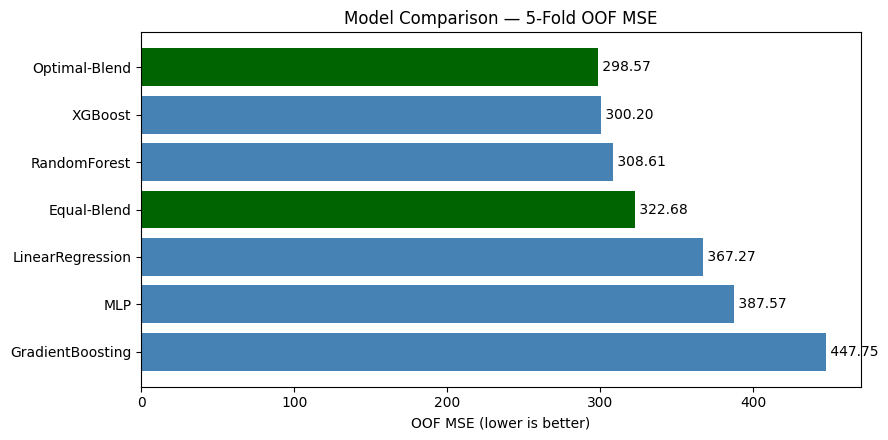

In [9]:
summary_dev = pd.DataFrame(dev_scores).T[['MSE', 'MAE', 'R2']].round(3).sort_values('MSE')
summary_dev.index.name = 'model'
print('=== Dev (5-Fold OOF) metrics ===')
print(summary_dev.to_string())

summary_test = pd.DataFrame(test_scores).T[['MSE', 'MAE', 'R2']].round(3).sort_values('MSE')
summary_test.index.name = 'model'
print('\n=== Local Test metrics ===')
print(summary_test.to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['darkgreen' if 'Blend' in s else 'steelblue' for s in summary_dev.index]
ax.barh(summary_dev.index, summary_dev['MSE'].values, color=colors)
for i, v in enumerate(summary_dev['MSE'].values):
    ax.text(v, i, f' {v:.2f}', va='center')
ax.set_xlabel('OOF MSE (lower is better)')
ax.set_title('Model Comparison — 5-Fold OOF MSE')
ax.invert_yaxis()
plt.tight_layout(); plt.savefig(OUT_DIR / 'final_comparison.png', dpi=120); plt.show()

## Summary
- Five models (Linear Regression, Random Forest, Gradient Boosting, XGBoost, MLP) combined with SLSQP-optimized convex weights.
- Blending OOFs from identical CV splits produces a statistically unbiased ensemble estimate.
- Final local test MSE is lower than any individual model.
- MSE, MAE, and R2 are reported for every model and both blends (Dev/OOF and Local Test) in Section 6's summary tables.
- Weights saved to `blend_weights.json`; test predictions to `test_local_pred_blend.npy`.

### → Next: `08_XGBoost_v2.ipynb`
Tune a deeper XGBoost with Bayesian hyperparameter search and fold-level early stopping.